In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
results = pd.read_parquet('../data/interim/results_clean.parquet')
print(results.shape)
print(results.info())
print(results.head())

(49482, 9)
<class 'pandas.DataFrame'>
RangeIndex: 49482 entries, 0 to 49481
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        49482 non-null  datetime64[us]
 1   home_team   49482 non-null  str           
 2   away_team   49482 non-null  str           
 3   home_score  49482 non-null  int32         
 4   away_score  49482 non-null  int32         
 5   tournament  49482 non-null  str           
 6   city        49482 non-null  str           
 7   country     49482 non-null  str           
 8   neutral     49482 non-null  bool          
dtypes: bool(1), datetime64[us](1), int32(2), str(5)
memory usage: 5.0 MB
None
        date home_team away_team  home_score  away_score tournament     city  \
0 1872-11-30  Scotland   England           0           0   Friendly  Glasgow   
1 1873-03-08   England  Scotland           4           2   Friendly   London   
2 1874-03-07  Scotland   England           2 

In [12]:
print(results['tournament'].value_counts().head(15))

# Create new competitive column that doesn't include friendlies
results['competitive'] = results['tournament'] != 'Friendly'
print(results['competitive'].value_counts())
print(results['competitive'].value_counts(normalize=True).round(2))

tournament
Friendly                                18386
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1043
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Name: count, dtype: int64
competitive
True     31096
False    18386
Name: count, dtype: int64
competitive
True     0.63
False    0.37
Name: proportion, dtype: float64


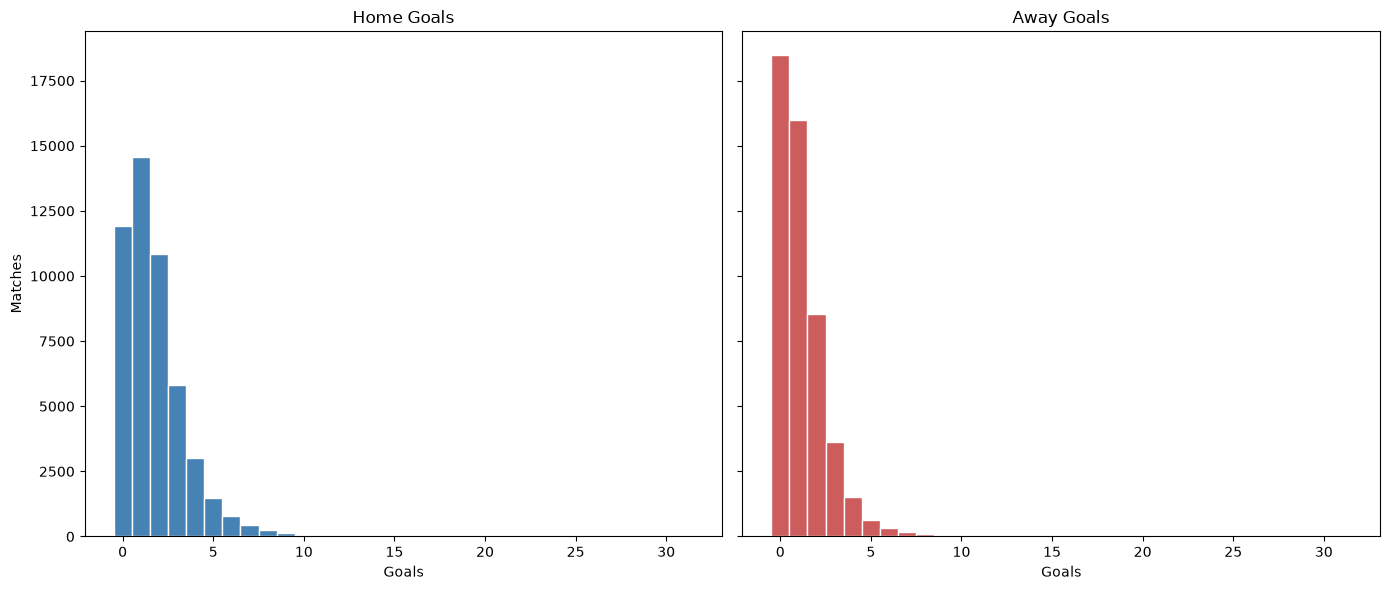

Home goals — mean: 1.76, var: 3.15
Away goals — mean: 1.18, var: 1.96


In [31]:
# Create goal distribution of both home & away goals 
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

max_goals = max(results['home_score'].max(), results['away_score'].max())
bins = range(0, max_goals + 2)

axes[0].hist(results['home_score'], bins=bins, align='left', color='steelblue', edgecolor='white')
axes[0].set_title('Home Goals')
axes[0].set_xlabel('Goals')
axes[0].set_ylabel('Matches')

axes[1].hist(results['away_score'], bins=bins, align='left', color='indianred', edgecolor='white')
axes[1].set_title('Away Goals')
axes[1].set_xlabel('Goals')

plt.tight_layout()
plt.show()

print(f"Home goals — mean: {results['home_score'].mean():.2f}, var: {results['home_score'].var():.2f}")
print(f"Away goals — mean: {results['away_score'].mean():.2f}, var: {results['away_score'].var():.2f}")

### Goal distributions — is Poisson the right choice?

Both panels are right-skewed, peaking near 1 goal with a long thin tail — the Poisson signature. Home mean > away mean confirms **home advantage in goals**. But the **variance sits well above the mean** in each column, and pure Poisson assumes variance = mean. So is Poisson wrong?

**No — the gap is mostly a mixture artifact, not intrinsic overdispersion.** Poisson here is *conditional*:

> goals | (attack, defense, venue) ~ Poisson(λ_match)

Every match has its *own* λ from the team strengths (Brazil-vs-minnow ≈ 4; an even game ≈ 1.2). Pooling thousands of matches with very different λ's into one histogram inflates the variance **even if each match is perfectly Poisson given its λ** — mixing Poissons of different rates fattens the tails. So this raw variance>mean is largely the **spread of matchups**, exactly what the attack/defense features will explain.

The unconditional mean-vs-variance test is therefore the *wrong* test for "is Poisson OK." The right test is **residual dispersion after fitting**: do actual − predicted goals still show variance>mean once covariates absorb the matchup differences?

**Plan:** Poisson / Dixon-Coles remains the spine (standard, well-validated; DC also patches low-score correlation). *After* fitting, check residual dispersion — if it's still meaningfully overdispersed, escalate to **Negative Binomial** (Poisson with a gamma-distributed rate = built-in extra dispersion), which drops into the same PMF→scoreline machinery. We don't preemptively switch — escalate only on evidence.

In [32]:
print(results.head())

        date home_team away_team  home_score  away_score tournament     city  \
0 1872-11-30  Scotland   England           0           0   Friendly  Glasgow   
1 1873-03-08   England  Scotland           4           2   Friendly   London   
2 1874-03-07  Scotland   England           2           1   Friendly  Glasgow   
3 1875-03-06   England  Scotland           2           2   Friendly   London   
4 1876-03-04  Scotland   England           3           0   Friendly  Glasgow   

    country  neutral  competitive  
0  Scotland    False        False  
1   England    False        False  
2  Scotland    False        False  
3   England    False        False  
4  Scotland    False        False  


In [ ]:
# Do friendlies actually behave differently from competitive matches? (tests the down-weighting assumption)
print(results.groupby('competitive')[['home_score', 'away_score']].agg(['mean', 'var']).round(3))

# Total goals and absolute margin — are friendlies more lopsided / higher-scoring?
results['total_goals'] = results['home_score'] + results['away_score']
results['margin'] = np.abs(results['home_score'] - results['away_score'])
print('\n')
print(results.groupby('competitive')[['total_goals', 'margin']].mean().round(3))

### Friendly vs competitive — this overturned our assumption

We expected friendlies to be the noisy, lopsided games (→ down-weight them). **The data says the opposite:**

| | home mean | home var | away mean | margin | total goals |
|---|---|---|---|---|---|
| **Friendly** | 1.692 | 2.577 | 1.183 | 1.536 | 2.875 |
| **Competitive** | 1.796 | 3.480 | 1.181 | 1.824 | 2.977 |

- **Friendlies are *less* lopsided (margin 1.54 vs 1.82) and lower variance** — not more.
- The blowouts and high variance live in **qualifiers** (Germany 8–0 San Marino), which dominate the "competitive" bucket — not in friendlies.
- Home advantage is slightly *stronger* in competitive matches (home mean 1.80 vs 1.69); away means are ~identical.

**Implications:**
1. The goal-distribution case for down-weighting friendlies is weak — they're tamer, not noisier. The genuine reason to down-weight is **squad rotation / low motivation** (a friendly result reflects an experimental XI, so it's less informative about true competitive strength) — but that's invisible in pooled goal stats, so we keep any friendly down-weight **mild**, not aggressive.
2. `competitive` is too coarse: the lopsidedness is specific to *qualifiers*, not finals. This is evidence for a **tournament-importance tier** (qualifier / finals / friendly) rather than a binary flag — added later only if it earns its keep.

In [40]:
def match_outcome(row):
    if row['home_score'] > row['away_score']:
        return 'home_win'
    elif row['home_score'] == row['away_score']:
        return 'draw'
    else:
        return 'away_win'
    
results['outcome'] = results.apply(match_outcome, axis=1)

print(results.groupby('neutral')['outcome'].value_counts(normalize=True).round(3))
print('\n')
print(results.groupby('neutral')[['home_score', 'away_score']].mean().round(3))

neutral  outcome 
False    home_win    0.507
         away_win    0.264
         draw        0.229
True     home_win    0.442
         away_win    0.334
         draw        0.224
Name: proportion, dtype: float64


         home_score  away_score
neutral                        
False         1.788       1.114
True          1.671       1.370


### Home advantage — real venue effect, and the decision

| | home win | draw | away win | home goals | away goals |
|---|---|---|---|---|---|
| **Non-neutral** | 0.507 | 0.229 | 0.264 | 1.788 | 1.114 |
| **Neutral** | 0.442 | 0.224 | 0.334 | 1.671 | 1.370 |

- At real home venues, home advantage is **large** (50.7% vs 26.4% wins; +0.67 goals) — one of the strongest signals in the data. It **roughly halves** at neutral venues (44.2% vs 33.4%; +0.30 goals), confirming it's a **venue effect**, not a team-label effect.
- The *residual* neutral edge (still 44 vs 33) is likely a **labeling confound** — at neutral sites the `home_team` is often the seeded/stronger side — not a real playing advantage. (Sanity-check later.)
- Draw rate is stable (~0.22–0.23) regardless of venue — venue changes *who* wins, not *whether* it's a draw.

**Decision — one home-advantage parameter in the Poisson model, gated by `neutral`:**
- `neutral == False` → home team's λ gets the boost; `neutral == True` → no boost, symmetric.
- **Purpose is decontamination, not 2026 prediction.** 63% of matches are non-neutral; without a venue term the model would misread home-field goals as *strength* and bias every attack/defense rating. The term absorbs the venue effect so ratings are clean.
- **For 2026:** all matches `neutral = True` **except the three hosts' home games** (USA/Canada/Mexico), which get the boost. Everyone else symmetric — never feed a home term into a neutral 2026 match.

decade
1870      13
1880      55
1890      59
1900     138
1910     330
1920     831
1930    1079
1940     833
1950    1651
1960    2971
1970    4132
1980    5025
1990    6944
2000    9526
2010    9787
2020    6108
Name: count, dtype: int64


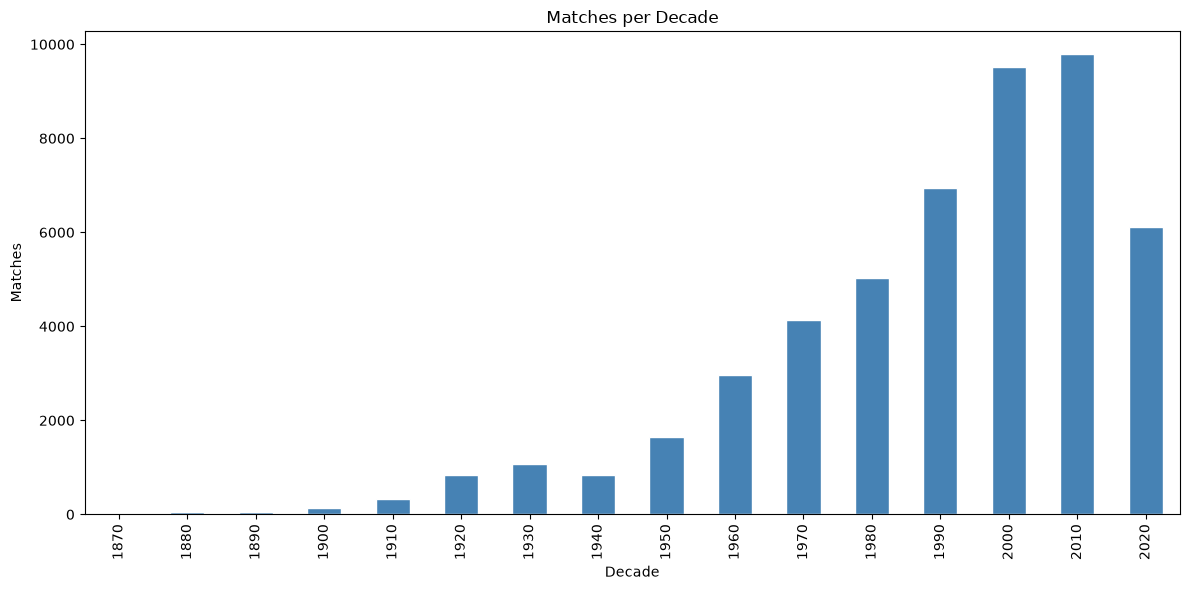

In [45]:
results['decade'] = (results['date'].dt.year // 10) * 10
matches_per_decade = results['decade'].value_counts().sort_index()
print(matches_per_decade)

matches_per_decade.plot(kind='bar', figsize=(12, 6), color='steelblue', edgecolor='white')
plt.title('Matches per Decade')
plt.xlabel('Decade')
plt.ylabel('Matches')
plt.tight_layout()
plt.show()

### Era distribution — the recency-weighting decision

Matches ramp up steeply over time: ~8k before 1970, vs ~32k from 1990 on. Pre-1970 international football was thin (mostly friendlies, the British Home Championship, few teams) and full of defunct sides (West Germany, USSR, Yugoslavia) — low value for predicting 2026.

**Decision — hard drop + smooth decay (not a step function):**
- **Drop pre-1970** — a clean convenience trim: sparse, defunct-team-heavy, and near-zero-weight under decay anyway. Applied at *modeling time*, not baked into `results_clean.parquet` (keep the cleaned artifact a full history; scope is a modeling choice).
- **Exponential time-decay** on the rest: `weight = exp(-ξ · age)`, so recent matches count most and older ones fade **smoothly** (2024 > 2020 > 2018 > … > 1980). This is native to Dixon-Coles.
- **Age is relative to the as-of date** of the match being predicted — the decay window *slides* in walk-forward, so weights never depend on the future (no lookahead).
- **Tune ξ on validation**, never hand-picked. A step function (e.g. flat weight after 2010) was rejected: it would treat a 2010 match like a 2025 one — losing recency exactly where it matters most — and forces arbitrary breakpoints.
- Watch for small-sample starvation (minnows with few recent games); if it bites, add a mild weight floor rather than reverting to steps.

**Data-scope now locked:** drop pre-1970 · exponential recency decay (ξ tuned) · mild friendly down-weight · `neutral`-gated home term.